In [1]:
# Importing necessary libraries
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [2]:
# Mounting Google Drive to access the dataset
from google.colab import drive
drive.mount('/content/drive')

MessageError: Error: credential propagation was unsuccessful

In [3]:
# Upload kaggle.json API key
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"madhushaley","key":"a355beeb19ea891a497bc712f5db50d8"}'}

In [4]:
# Setting up Kaggle API
import os
os.makedirs('/root/.kaggle', exist_ok=True)
os.rename('/content/kaggle.json', '/root/.kaggle/kaggle.json')
os.chmod('/root/.kaggle/kaggle.json', 600)

In [5]:
# Download the chest xray dataset from Kaggle
!kaggle datasets download -d paultimothymooney/chest-xray-pneumonia

Dataset URL: https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia
License(s): other
100% 2.29G/2.29G [00:15<00:00, 159MB/s] 



In [6]:
# Unzip the downloaded dataset
import zipfile

with zipfile.ZipFile('/content/chest-xray-pneumonia.zip', 'r') as zip_ref:
    zip_ref.extractall('/content/chest_xray')

print("Dataset extracted successfully!")

Dataset extracted successfully!


In [7]:
# Check dataset structure
import os

base_dir = '/content/chest_xray/chest_xray'

print("Folders inside chest_xray:")
print(os.listdir(base_dir))

print("\nFolders inside train:")
print(os.listdir(base_dir + '/train'))

print("\nTraining NORMAL images:", len(os.listdir(base_dir + '/train/NORMAL')))
print("Training PNEUMONIA images:", len(os.listdir(base_dir + '/train/PNEUMONIA')))

Folders inside chest_xray:
['test', '__MACOSX', 'train', 'val', 'chest_xray']

Folders inside train:
['NORMAL', 'PNEUMONIA']

Training NORMAL images: 1341
Training PNEUMONIA images: 3875


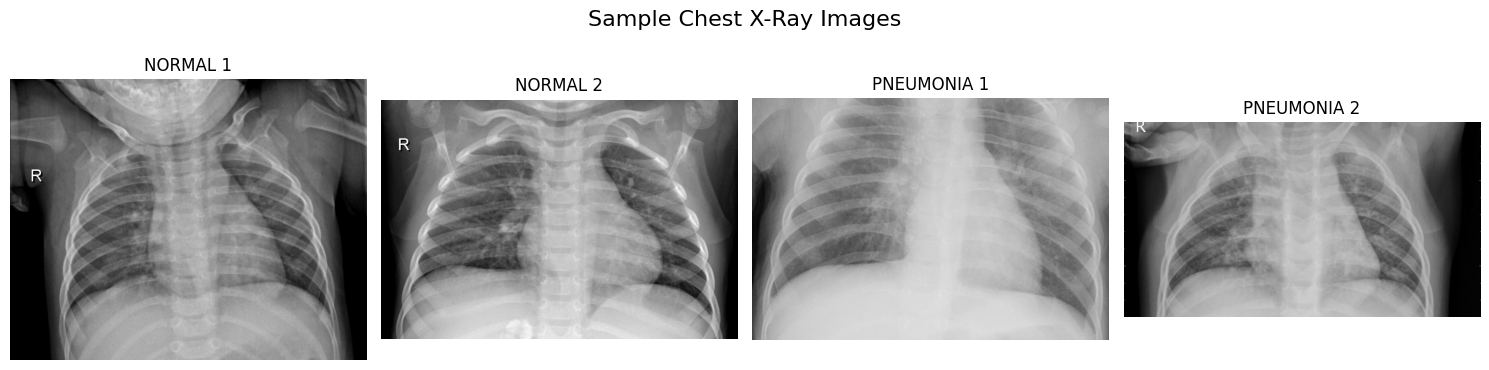

In [8]:
# Visualize sample images from dataset
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

fig, axes = plt.subplots(1, 4, figsize=(15, 4))

# 2 Normal images
normal_dir = base_dir + '/train/NORMAL/'
normal_images = os.listdir(normal_dir)

axes[0].imshow(mpimg.imread(normal_dir + normal_images[0]), cmap='gray')
axes[0].set_title('NORMAL 1')
axes[0].axis('off')

axes[1].imshow(mpimg.imread(normal_dir + normal_images[1]), cmap='gray')
axes[1].set_title('NORMAL 2')
axes[1].axis('off')

# 2 Pneumonia images
pneumonia_dir = base_dir + '/train/PNEUMONIA/'
pneumonia_images = os.listdir(pneumonia_dir)

axes[2].imshow(mpimg.imread(pneumonia_dir + pneumonia_images[0]), cmap='gray')
axes[2].set_title('PNEUMONIA 1')
axes[2].axis('off')

axes[3].imshow(mpimg.imread(pneumonia_dir + pneumonia_images[1]), cmap='gray')
axes[3].set_title('PNEUMONIA 2')
axes[3].axis('off')

plt.suptitle('Sample Chest X-Ray Images', fontsize=16)
plt.tight_layout()
plt.show()

In [9]:
# Preprocessing and loading images
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Normalize pixel values and apply data augmentation for training
train_datagen = ImageDataGenerator(
    rescale = 1./255,
    zoom_range = 0.2,
    horizontal_flip = True
)

# Only normalize for testing (no augmentation)
test_datagen = ImageDataGenerator(rescale = 1./255)

In [10]:
# Loading images from folders
train_generator = train_datagen.flow_from_directory(
    base_dir + '/train',
    target_size = (150, 150),
    batch_size = 32,
    class_mode = 'binary'
)

test_generator = test_datagen.flow_from_directory(
    base_dir + '/test',
    target_size = (150, 150),
    batch_size = 32,
    class_mode = 'binary'
)

Found 5216 images belonging to 2 classes.
Found 624 images belonging to 2 classes.


In [11]:
# Building the CNN model
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

model = Sequential([
    # First Convolutional Layer
    Conv2D(32, (3,3), activation='relu', input_shape=(150, 150, 3)),
    MaxPooling2D(2, 2),

    # Second Convolutional Layer
    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2, 2),

    # Third Convolutional Layer
    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2, 2),

    # Fully Connected Layers
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 36992)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     4,735,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,828,481 (18.42 MB)

 Trainable params: 4,828,481 (18.42 MB)

 Non-trainable params: 0 (0.00 B)

In [12]:
# Compiling the model
model.compile(
    optimizer = 'adam',
    loss = 'binary_crossentropy',
    metrics = ['accuracy']
)

In [13]:
# Training the model
history = model.fit(
    train_generator,
    epochs = 10,
    validation_data = test_generator
)

Epoch 1/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 320s 2s/step - accuracy: 0.7960 - loss: 0.4366 - val_accuracy: 0.7708 - val_loss: 0.4923
Epoch 2/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 329s 2s/step - accuracy: 0.8721 - loss: 0.2959 - val_accuracy: 0.8173 - val_loss: 0.4303
Epoch 3/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 319s 2s/step - accuracy: 0.8953 - loss: 0.2511 - val_accuracy: 0.8638 - val_loss: 0.3819
Epoch 4/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 324s 2s/step - accuracy: 0.9087 - loss: 0.2320 - val_accuracy: 0.8093 - val_loss: 0.5481
Epoch 5/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 314s 2s/step - accuracy: 0.9132 - loss: 0.2245 - val_accuracy: 0.8750 - val_loss: 0.3575
Epoch 6/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 322s 2s/step - accuracy: 0.9247 - loss: 0.1939 - val_accuracy: 0.8910 - val_loss: 0.3452
Epoch 7/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 319s 2s/step - accuracy: 0.9348 - loss: 0.1730 - val_accuracy: 0.7901 - val_loss: 0.7061
Epoch 8/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 325s 2s/step - accuracy: 0.9377 - loss: 0.1704 - val_accu

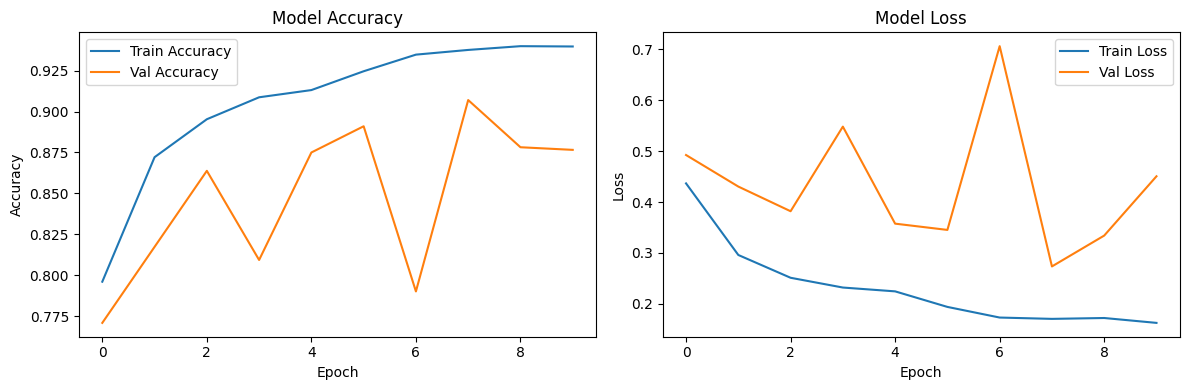

In [14]:
# Plotting accuracy and loss graphs
plt.figure(figsize=(12, 4))

# Accuracy graph
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Loss graph
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

In [15]:
# Evaluating the model on test data
test_loss, test_accuracy = model.evaluate(test_generator)
print(f"Test Accuracy: {test_accuracy*100:.2f}%")
print(f"Test Loss: {test_loss:.4f}")

20/20 ━━━━━━━━━━━━━━━━━━━━ 15s 762ms/step - accuracy: 0.8766 - loss: 0.4505
Test Accuracy: 87.66%
Test Loss: 0.4505


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 197ms/step


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


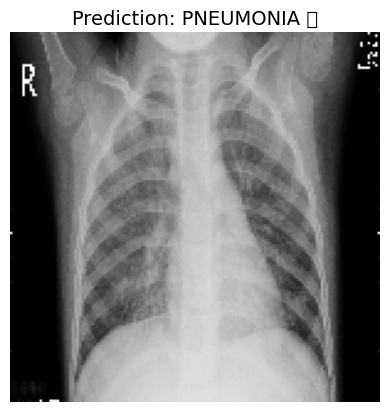

In [16]:
# Predicting on a single image
import numpy as np
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt

# Pick a test image
test_image_path = base_dir + '/test/PNEUMONIA/' + os.listdir(base_dir + '/test/PNEUMONIA/')[0]

# Load and preprocess
img = image.load_img(test_image_path, target_size=(150, 150))
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)
img_array = img_array / 255.0

# Predict
prediction = model.predict(img_array)

# Show result
plt.imshow(img)
plt.axis('off')
if prediction[0][0] > 0.5:
    plt.title('Prediction: PNEUMONIA 🔴', fontsize=14)
else:
    plt.title('Prediction: NORMAL 🟢', fontsize=14)
plt.show()